<a href="https://colab.research.google.com/github/AryasatyaChandra/QSAR-DPP4/blob/main/Curcuma%20Longa%20QSAR%20DPP-4/QSAR_DPP_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Build a QSAR model in 8 lines of Python
When I encounter a new dataset.  I often want to construct a simple model to get a quick idea of how easy or hard it will be to model the data.  Over the years, I've put together several scripts to do this.  Recently, I've come across a few Python packages that make this whole task a lot easier.  One thing I like about the workflow below is that it's flexible.  I can change the input format, the descriptors, or the machine learning model by changing one line of code.  This script doesn't take the place of rigorous validation but it provides a quick place to start.  

Ok, I admit that there are more than 8 lines of code here.  I added some more to illustrate what we're doing.  However, there are only **8 lines** here that are critical.

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !uv pip install --system rdkit pandas datamol molfeat numpy scikit-learn yellowbrick wget

Using Python 3.12.13 environment at: /usr
Resolved 91 packages in 4.72s
Prepared 16 packages in 5.08s
Uninstalled 2 packages in 33ms
Installed 16 packages in 420ms
 + aiobotocore==3.7.0
 + aioitertools==0.13.0
 + botocore==1.43.0
 + datamol==0.12.5
 - fsspec==2025.3.0
 + fsspec==2026.6.0
 - gcsfs==2025.3.0
 + gcsfs==2026.7.0
 + google-cloud-storage-control==1.12.0
 + jmespath==1.1.0
 + loguru==0.7.3
 + molfeat==0.11.0
 + mordredcommunity==2.0.7
 + pmapper==1.1.3
 + rdkit==2026.3.3
 + s3fs==2026.6.0
 + selfies==2.2.0
 + wget==3.2


In [ ]:
import pandas as pd
import datamol as dm
from molfeat.calc import FPCalculator
from molfeat.trans import MoleculeTransformer
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from yellowbrick.regressor import prediction_error, residuals_plot
import wget


df_raw = pd.read_csv("dpp4.csv", sep=";")

df_raw = df_raw.dropna(subset=['Smiles', 'Standard Value'])
df_raw = df_raw[(df_raw['Standard Type'] == 'IC50') & (df_raw['Standard Units'] == 'nM')]
df_raw['Standard Value'] = pd.to_numeric(df_raw['Standard Value'], errors='coerce')
df_raw = df_raw.dropna(subset=['Standard Value'])

df_raw['pIC50'] = 9 - np.log10(df_raw['Standard Value'])

df_clean = pd.DataFrame({
    'SMILES': df_raw['Smiles'],
    'Name': df_raw['Molecule ChEMBL ID'],
    'pIC50': df_raw['pIC50']
})

df_clean = df_clean.groupby(['Name', 'SMILES'], as_index=False).mean()
df_clean = df_clean[['SMILES', 'Name', 'pIC50']] # Susun urutan kolomnya

df_clean.to_csv("dpp4_ml.csv", index=False)
print(f"Done! {len(df_clean)} data ready for machine learning.")

Done! 4739 data ready for machine learning.


# **0.** Get an input file.  
To start we need a csv file with Chemical structures as SMILES and some property or actvity file.  The file should have a column named **SMILES** and an activity column whose name we will specify below.  If you're running in Google Colab, you'll need to upload the file from your local machine you can do this by first clicking on the **Files** icon on the left, then clicking on the "Upload to session storage" icon in the menu that opens up.  After that, you should see the file in the file explorer on the left.

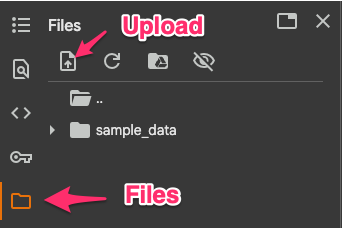

The code below will download a demo file called "carbonic.csv" from GitHub.  If you don't have your own csv file, you can use this one to try out the code below.

In [ ]:
wget.download("https://raw.githubusercontent.com/PatWalters/datafiles/refs/heads/main/carbonic.csv")

'carbonic.csv'

## **1.** Read the data into a [Pandas](https://pandas.pydata.org/) dataframe.    
In the next cell we read the data from a csv file and put it into a Pandas dataframe, a structure that holds a datatable in memory for a Python script to use. If you want to use your own csv file, upload it as described above, then change
```python
filename = "dpp4_ml.csv"
```
to
```python
filename = "myfile.csv"
```
where `myfile.csv` is the name of the file you uploaded.  The code below uses the last column in the dataframe as the the acivity column.  If this isn't the case, change the code below to assign the correct column.

In [ ]:
filename = "dpp4_ml.csv"
df = pd.read_csv(filename)
activity_col = df.columns[-1]
print(f"The activity column is proably {activity_col}")
df.head()

The activity column is proably pIC50


,SMILES,Name,pIC50
0,N[C@@H](CCNCc1ccc(Cl)cc1)C(=O)N1CC=CCC1,CHEMBL100370,3.829738
1,NCC[C@H](NCc1ccccc1)C(=O)N1CCCCC1,CHEMBL100715,3.000000
2,NC(N)=NCC[C@H](N)C(=O)N1CCCCC1,CHEMBL101401,3.263603
3,NCC[C@H](N=C(N)N)C(=O)N1CCCCC1,CHEMBL101656,3.000000
4,Cl.N#C[C@@H]1CCCN1C(=O)CN[C@@H]1C[C@@H]2C[C@H]...,CHEMBL1082345,6.917215


## **2.** Instantiate a Fingerprint calculator from the awesome [molfeat](https://m2d2.io/blog/posts/introducing-molfeat-a-hub-of-molecular-featurizers/) package. This package has several descriptor types available.
```python
>>> from molfeat.calc import FP_FUNCS
>>> FP_FUNCS.keys()
dict_keys(['maccs', 'avalon', 'ecfp', 'fcfp', 'topological', 'atompair', 'rdkit', 'pattern', 'layered', 'map4', 'secfp', 'erg', 'estate', 'avalon-count', 'rdkit-count', 'ecfp-count', 'fcfp-count', 'topological-count', 'atompair-count'])
```

In [ ]:
calc = FPCalculator("ecfp")

## **3.** Instantiate a molecule transfomer from molfeat.    
This object takes a list of SMILES as input and returns descriptors.  It's very flexible and can run in parallel.  [Check it out!](https://molfeat-docs.datamol.io/stable/tutorials/types_of_featurizers.html)

In [ ]:
trans = MoleculeTransformer(calc)

## **4-5.** Calculate the fingerprints.    
Note the use of the function from [datamol](https://datamol.io) that silences logging messages from the RDKit.  This is more polite version of my rd_shut_the_hell_up function in [useful_rdkit_utils](https://github.com/PatWalters/useful_rdkit_utils).

In [ ]:
%%time
with dm.without_rdkit_log():
    df['fp'] = trans.transform(df.SMILES.values)

CPU times: user 1.81 s, sys: 103 ms, total: 1.92 s
Wall time: 1.92 s


## **6.** Split the data into training and test sets.  
I like to do this with dataframes.  That way I don't have to remember the order in which `train_X, test_X, train_y, and test_y` are returned by [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [ ]:
train, test = train_test_split(df)

## **7.** Instantiate an sklearn style regressor.  
In this case I used [HistGradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html), which is the scikit-learn implementation of [LightGBM](https://lightgbm.readthedocs.io/en/latest/Python-Intro.html).  You can easily plug in any scikit-learn compatible regressor like [RandomForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) or [XGBoost](https://xgboost.readthedocs.io/en/stable/python/python_intro.html).
```python
from lightgbm import LGBMRegressor
model = LGBMRegressor()
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
from xgboost import XGBRegressor
model = XGBRegressor()
```

In [ ]:
model = HistGradientBoostingRegressor()

## **8.** Use [YellowBrick](https://www.scikit-yb.org/en/latest/) to build a model and visualize its performance.
The **Loss** reported in the plot below is the [$R^2$](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html) for the model.

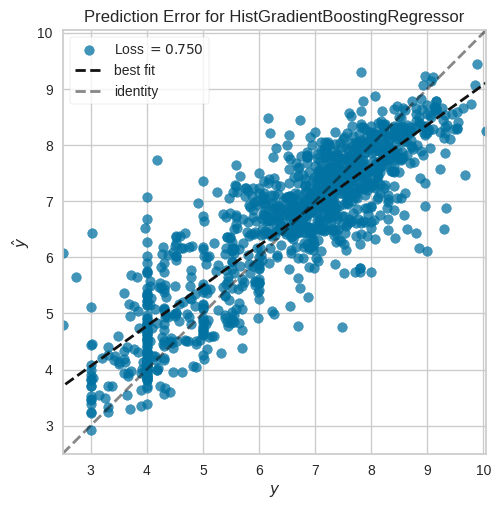

CPU times: user 20.7 s, sys: 714 ms, total: 21.4 s
Wall time: 27.8 s


In [ ]:
%%time
visualizer = prediction_error(model,np.stack(train.fp),train[activity_col],np.stack(test.fp),test[activity_col])

### Bonus
Plot the residuals for the training and test sets

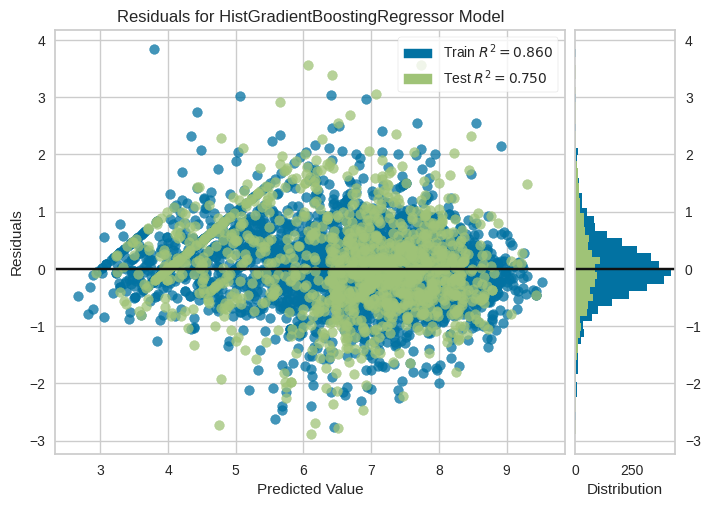

In [ ]:
viz = residuals_plot(model,np.stack(train.fp), train[activity_col], np.stack(test.fp), test[activity_col], is_fitted=True)

In [ ]:
test['predicted_pIC50'] = model.predict(np.stack(test.fp))

# Sort by predicted_pIC50 in descending order to find the 'best' compounds
best_compounds = test.sort_values(by='predicted_pIC50', ascending=False)

print("Top 10 compounds by predicted pIC50:")
print(best_compounds[['SMILES', 'Name', activity_col, 'predicted_pIC50']].head(10))

# You can also save this data to a CSV file if needed:
# best_compounds[['SMILES', 'Name', activity_col, 'predicted_pIC50']].to_csv('predicted_best_compounds.csv', index=False)

Top 10 compounds by predicted pIC50:
                                                 SMILES           Name  \
2605  N#Cc1ccc(N[C@@H]2CN[C@H](C(=O)N3CCC[C@H]3C#N)C...   CHEMBL370046   
3971  CC(C)=CCC/C(C)=C/OC(=O)[C@@H]1CCCN1C(=O)[C@@H]...  CHEMBL5220348   
4022  CN1CCN(S(=O)(=O)c2cccc(C(=O)NC[C@@H]3CCCN3C(=O...  CHEMBL5275046   
916   O=C([C@@H]1C[C@H](N2CCN(c3nc4ccccc4[nH]3)CC2)C...  CHEMBL2058760   
4031  N[C@@H](CC(=O)N1CCC[C@H]1CNC(=O)c1cccc(S(N)(=O...  CHEMBL5276657   
3975  CCOC(=O)/C=C/OC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCC...  CHEMBL5220613   
919   O=C([C@@H]1C[C@H](N2CCN(c3nc4ccccc4o3)CC2)CN1)...  CHEMBL2058967   
2736  Cc1ccn2nc3c(c2n1)CN([C@@H]1CO[C@H](c2cc(F)c(F)...  CHEMBL3804940   
2653  N[C@H]1C[C@@H](N2Cc3[nH]nc(NS(=O)(=O)CC(F)(F)F...  CHEMBL3735461   
4032  N[C@H]1C[C@@H](N2Cc3cnn(S(=O)(=O)c4ccc(C(F)(F)...  CHEMBL5276887   

         pIC50  predicted_pIC50  
2605  9.886057         9.437865  
3971  7.815309         9.301112  
4022  8.958607         9.229925  
916   9.0969

In [ ]:
# Save the test set with actual and predicted pIC50 values to a CSV file
test[['SMILES', 'Name', activity_col, 'predicted_pIC50']].to_csv('all_test_compounds_with_predictions.csv', index=False)
print("Saved 'all_test_compounds_with_predictions.csv' containing all test compounds with their actual and predicted pIC50 values.")

Saved 'all_test_compounds_with_predictions.csv' containing all test compounds with their actual and predicted pIC50 values.


In [ ]:
import numpy as np # Ensure numpy is imported
import datamol as dm # Ensure datamol is imported
from molfeat.trans import MoleculeTransformer # Ensure MoleculeTransformer is imported
from molfeat.calc import FPCalculator # Ensure FPCalculator is imported

# --- Step 2: Load the cleaned data, calculate fingerprints, and make predictions ---

# Define the filename to load (which was just created/updated in the previous cell)
curcuma_longa_data_file = 'curcuma_longa_predictions_input.csv'

try:
    df_curcuma = pd.read_csv(curcuma_longa_data_file)
    print(f"Loaded {len(df_curcuma)} compounds from '{curcuma_longa_data_file}' for prediction.")
    display(df_curcuma.head())
except FileNotFoundError:
    print(f"Error: The file '{curcuma_longa_data_file}' was not found. Please ensure the previous CID to SMILES conversion step ran successfully.")
    df_curcuma = pd.DataFrame({'SMILES': [], 'Name': []}) # Ensure this DataFrame is defined

# Calculate fingerprints using the existing `trans` object
if not df_curcuma.empty and 'SMILES' in df_curcuma.columns:
    # Re-instantiate the transformer if `trans` was not globally available or reset
    # This assumes `calc` and `model` are still available from previous cells.
    try:
        if 'trans' not in locals():
            calc = FPCalculator("ecfp") # Assuming ecfp was used
            trans = MoleculeTransformer(calc)
        if 'model' not in locals():
             print("Warning: 'model' not found. Please ensure the model training cells have been run.")
             # Exit or raise error if model is critical and not available
             df_curcuma = pd.DataFrame() # Clear df_curcuma to prevent further errors
    except NameError:
        print("Error: `trans` or `model` objects are not defined. Please ensure prior setup cells are run.")
        df_curcuma = pd.DataFrame() # Clear df_curcuma to prevent further errors

    if not df_curcuma.empty:
        with dm.without_rdkit_log():
            df_curcuma['fp'] = trans.transform(df_curcuma.SMILES.values)
        print("Fingerprints calculated for Curcuma longa compounds.")
        display(df_curcuma.head())
else:
    print("Cannot calculate fingerprints: Curcuma longa DataFrame is empty or missing 'SMILES' column.")

# Predict pIC50 and convert to IC50 (nM)
if not df_curcuma.empty and 'fp' in df_curcuma.columns and 'model' in locals():
    df_curcuma['predicted_pIC50'] = model.predict(np.stack(df_curcuma.fp.values))

    # Convert predicted pIC50 back to IC50 (nM)
    # pIC50 = 9 - log10(IC50_nM)
    # log10(IC50_nM) = 9 - pIC50
    # IC50_nM = 10^(9 - pIC50)
    df_curcuma['predicted_IC50_nM'] = 10**(9 - df_curcuma['predicted_pIC50'])

    # Sort by predicted_pIC50 in descending order to find the 'best' compounds
    best_curcuma_compounds = df_curcuma.sort_values(by='predicted_pIC50', ascending=False)

    print("\nTop 10 Curcuma longa compounds by predicted pIC50 and their predicted IC50:")
    display(best_curcuma_compounds[['SMILES', 'Name', 'predicted_pIC50', 'predicted_IC50_nM']].head(10))

    # Save the full results to a new CSV file
    best_curcuma_compounds[['SMILES', 'Name', 'predicted_pIC50', 'predicted_IC50_nM']].to_csv('curcuma_longa_predictions.csv', index=False)
    print("\nFull prediction results saved to 'curcuma_longa_predictions.csv'")
else:
    print("Cannot predict pIC50/IC50: Curcuma longa DataFrame is empty, fingerprints are missing, or the model is not available.")


Loaded 0 compounds from 'curcuma_longa_predictions_input.csv' for prediction.


,SMILES,Name


Cannot calculate fingerprints: Curcuma longa DataFrame is empty or missing 'SMILES' column.
Cannot predict pIC50/IC50: Curcuma longa DataFrame is empty, fingerprints are missing, or the model is not available.


### Step 1: Clean Compound Data
Extract CIDs and Names from the uploaded file.

In [ ]:
import pandas as pd

pubchem_input = 'pubchem_curcuma_longa.csv'
cleaned_list_file = 'curcuma_longa_cleaned_list.csv'

try:
    df_raw_curcuma = pd.read_csv(pubchem_input)
    # Map columns
    cid_col = 'Compound_CID'
    name_col = 'Compound Name' if 'Compound Name' in df_raw_curcuma.columns else ('Compound' if 'Compound' in df_raw_curcuma.columns else None)

    df_list = df_raw_curcuma[[cid_col]].copy()
    df_list.columns = ['CID']
    df_list['Name'] = df_raw_curcuma[name_col] if name_col else df_list['CID'].apply(lambda x: f"CID_{x}")

    df_list = df_list.dropna(subset=['CID']).drop_duplicates(subset=['CID'])
    df_list['CID'] = df_list['CID'].astype(int)

    df_list.to_csv(cleaned_list_file, index=False)
    print(f"Cleaned list saved to {cleaned_list_file}. Total unique compounds: {len(df_list)}")
    display(df_list.head())
except Exception as e:
    print(f"Error cleaning data: {e}")

Cleaned list saved to curcuma_longa_cleaned_list.csv. Total unique compounds: 633


,CID,Name
0,126,4-Hydroxybenzaldehyde
1,135,4-Hydroxybenzoic Acid
2,206,Hexose
3,239,Beta-Alanine
4,240,Benzaldehyde


### Step 2: Convert CIDs to SMILES (Robust & Resumable)
Fetches molecular structures from PubChem. Run this cell again if it gets interrupted.

In [ ]:
import os
import pubchempy as pcp
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type

input_list = 'curcuma_longa_cleaned_list.csv'
output_smiles = 'curcuma_longa_with_smiles.csv'

@retry(wait=wait_exponential(multiplier=1, min=2, max=30), stop=stop_after_attempt(4), reraise=True,
       retry=retry_if_exception_type(pcp.PubChemHTTPError))
def get_smiles(cid):
    c = pcp.Compound.from_cid(cid)
    return c.canonical_smiles if c else None

df_to_process = pd.read_csv(input_list)

# Resume logic
if os.path.exists(output_smiles):
    df_done = pd.read_csv(output_smiles)
    done_cids = set(df_done['CID'].tolist())
    results = df_done.to_dict('records')
    print(f"Resuming: {len(done_cids)} already done.")
else:
    done_cids = set()
    results = []

print("Starting SMILES retrieval...")
for idx, row in df_to_process.iterrows():
    if row['CID'] in done_cids: continue

    try:
        smi = get_smiles(int(row['CID']))
        if smi:
            results.append({'CID': row['CID'], 'Name': row['Name'], 'SMILES': smi})
        done_cids.add(row['CID'])
    except Exception as e:
        print(f"Skipping CID {row['CID']} due to error.")

    if (len(done_cids)) % 20 == 0:
        pd.DataFrame(results).to_csv(output_smiles, index=False)
        print(f"Progress: {len(done_cids)}/{len(df_to_process)} compounds checked...")

df_final_smiles = pd.DataFrame(results)
df_final_smiles.to_csv(output_smiles, index=False)
print(f"Finished! {len(df_final_smiles)} compounds have SMILES.")

Resuming: 632 already done.
Starting SMILES retrieval...
Finished! 633 compounds have SMILES.


/tmp/ipykernel_946/2296840860.py:12: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  return c.canonical_smiles if c else None


### Step 3: Predict DPP-4 Activity
Calculate fingerprints and apply the trained model.

In [ ]:
import numpy as np
import datamol as dm

if 'model' not in locals():
    print("Error: Model not found. Please run the training cells first.")
else:
    df_predict = pd.read_csv('curcuma_longa_with_smiles.csv')

    with dm.without_rdkit_log():
        df_predict['fp'] = trans.transform(df_predict['SMILES'].values)

    X_new = np.stack(df_predict['fp'].values)
    df_predict['predicted_pIC50'] = model.predict(X_new)
    df_predict['predicted_IC50_nM'] = 10**(9 - df_predict['predicted_pIC50'])

    # Final sorting and cleanup
    df_results = df_predict[['Name', 'CID', 'SMILES', 'predicted_pIC50', 'predicted_IC50_nM']].sort_values('predicted_pIC50', ascending=False)

    df_results.to_csv('curcuma_longa_dpp4_predictions.csv', index=False)
    print("Predictions complete. Top results:")
    display(df_results.head(10))

Predictions complete. Top results:


,Name,CID,SMILES,predicted_pIC50,predicted_IC50_nM
83,Congo red,11313,C1=CC=C2C(=C1)C(=CC(=C2N)N=NC3=CC=C(C=C3)C4=CC...,6.315105,484.054915
605,"(2Z,4E)-3-hydroxy-5-(4-hydroxy-3-methoxyphenyl...",102230690,CC1=CC2C(CC1C(C2C3=CC(=C(C=C3)O)OC)C(=O)C=C(C=...,6.308835,491.094498
606,"(2Z,4E)-3-hydroxy-5-(4-hydroxy-3-methoxyphenyl...",102230691,CC1=CC2C(CC1C(C2C3=CC(=C(C=C3)O)OC)C(=O)C=C(C=...,6.308835,491.094498
35,CID 6037,6037,C1=CC(=CC=C1C(=O)NC(CCC(=O)O)C(=O)O)NCC2=CN=C3...,6.259568,550.087174
260,Npc215743,615367,CC1(CC(=CC23C14C2CC(C4)C3(C)C)C=O)C,6.226095,594.161676
600,"1-[(3R,6S)-6-hydroxy-6'-[(E)-2-(4-hydroxypheny...",102230685,CC1CC2CC(C(=CC2OC13CC(C(=C(O3)C=CC4=CC=C(C=C4)...,6.207106,620.717616
604,"(2Z,4E)-3-hydroxy-5-(4-hydroxy-3-methoxyphenyl...",102230689,CC1=CC2C(CC1C(C2C(=O)C=C(C=CC3=CC(=C(C=C3)O)OC...,6.199715,631.371059
602,"(2Z,4E)-3-hydroxy-5-(4-hydroxy-3-methoxyphenyl...",102230687,CC1=CC2C(CC1C(C2C(=O)C=C(C=CC3=CC(=C(C=C3)O)OC...,6.199715,631.371059
607,"(1E,6E)-4-[4,8-dimethyl-6-(2-methylprop-1-enyl...",102230692,CC1CC(C2CC1C(C=C2C)C(C(=O)C=CC3=CC(=C(C=C3)O)O...,6.191422,643.543704
565,"2-[2-(5,5,8a-trimethyl-2-methylidene-3,4,4a,6,...",75094027,CC1(CCCC2(C1CCC(=C)C2CC=C(CC=O)C=O)C)C,6.173526,670.615728


### Comparison of pIC50 Distributions
This plot compares the activity range of the ChEMBL training data against the predicted activity of the *Curcuma longa* compounds.

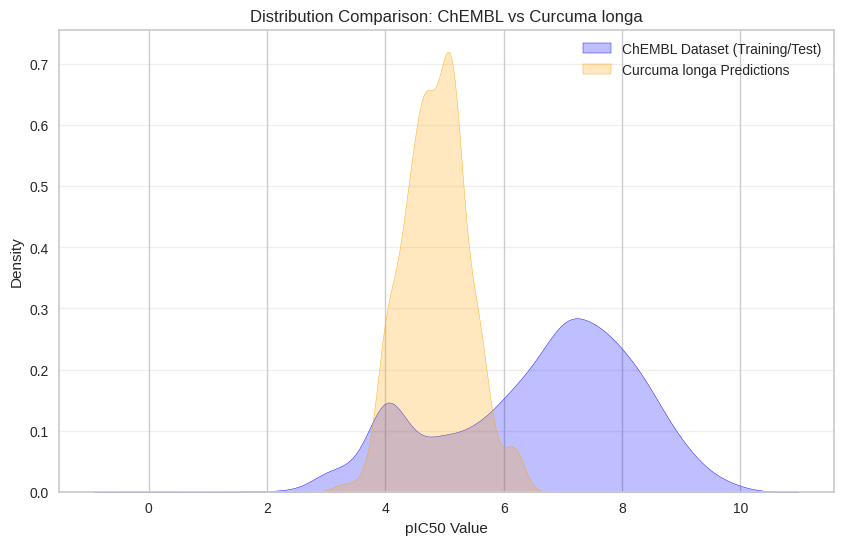

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df['pIC50'], label='ChEMBL Dataset (Training/Test)', fill=True, color='blue')
sns.kdeplot(df_results['predicted_pIC50'], label='Curcuma longa Predictions', fill=True, color='orange')

plt.title('Distribution Comparison: ChEMBL vs Curcuma longa')
plt.xlabel('pIC50 Value')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Feature Importance
Using Permutation Importance to identify which fingerprint bits contribute most to the model's performance.

Calculating feature importance via permutation (this may take a moment)...


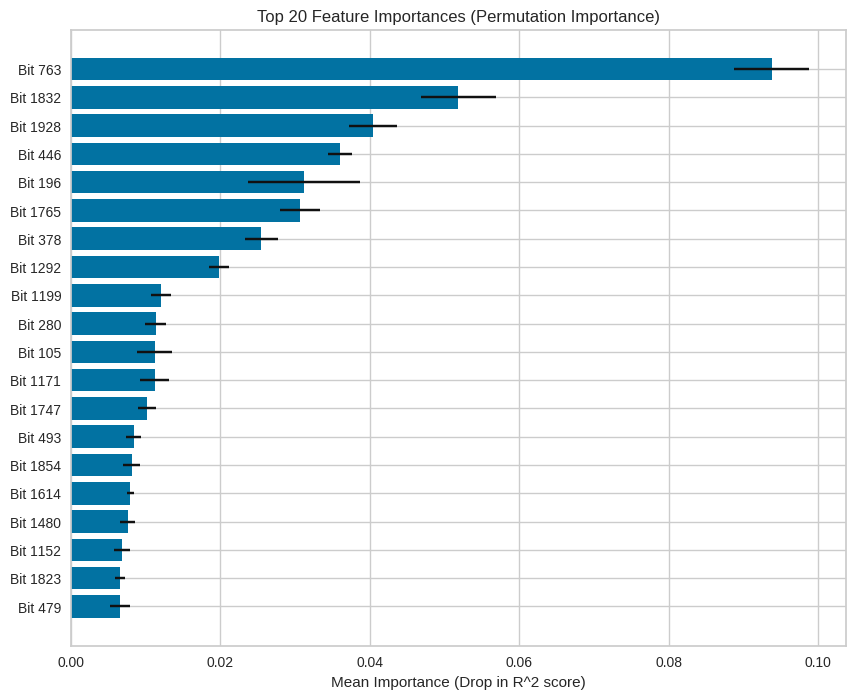

In [ ]:
from sklearn.inspection import permutation_importance

# We use a subset of the test set for speed in calculating permutation importance
print("Calculating feature importance via permutation (this may take a moment)...")
r = permutation_importance(model, np.stack(test.fp), test[activity_col], n_repeats=5, random_state=42)

# Get top 20 influential bits
indices = np.argsort(r.importances_mean)[-20:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), r.importances_mean[indices], xerr=r.importances_std[indices], align='center')
plt.yticks(range(len(indices)), [f'Bit {i}' for i in indices])
plt.title('Top 20 Feature Importances (Permutation Importance)')
plt.xlabel('Mean Importance (Drop in R^2 score)')
plt.show()

### Checking for Overlap Between Datasets
We will compare the SMILES in the *Curcuma longa* set with the SMILES used in the ChEMBL training/test set to see if any actual activity data is already known.

In [ ]:
import pandas as pd

# Standardize SMILES for comparison by ensuring they are canonical (datamol helps here)
# We'll compare the Curcuma results with the original cleaned ChEMBL dataframe 'df'

# Create a mapping of SMILES to Actual pIC50 from the training data
chembl_lookup = df[['SMILES', 'pIC50', 'Name']].copy()
chembl_lookup.columns = ['SMILES', 'actual_pIC50', 'ChEMBL_ID']

# Merge the Curcuma results with the ChEMBL lookup table
overlap_df = pd.merge(df_results, chembl_lookup, on='SMILES', how='inner')

if not overlap_df.empty:
    print(f"Found {len(overlap_df)} overlapping compounds!")
    # Calculate error for these compounds
    overlap_df['error'] = overlap_df['actual_pIC50'] - overlap_df['predicted_pIC50']
    display(overlap_df[['Name', 'ChEMBL_ID', 'SMILES', 'actual_pIC50', 'predicted_pIC50', 'error']])
else:
    print("No exact SMILES overlap found between Curcuma longa and the training dataset.")

No exact SMILES overlap found between Curcuma longa and the training dataset.


### Model Performance Metrics
Calculating R², RMSE, and MAE for the research report.

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Predictions for training and test sets
y_train_pred = model.predict(np.stack(train.fp))
y_test_pred = model.predict(np.stack(test.fp))

y_train_true = train[activity_col]
y_test_true = test[activity_col]

# Calculate Metrics
metrics = {
    "Metric": ["R2", "RMSE", "MAE"],
    "Train": [
        r2_score(y_train_true, y_train_pred),
        np.sqrt(mean_squared_error(y_train_true, y_train_pred)),
        mean_absolute_error(y_train_true, y_train_pred)
    ],
    "Test": [
        r2_score(y_test_true, y_test_pred),
        np.sqrt(mean_squared_error(y_test_true, y_test_pred)),
        mean_absolute_error(y_test_true, y_test_pred)
    ]
}

df_metrics = pd.DataFrame(metrics)
display(df_metrics)

# Optional: Save to CSV for your records
df_metrics.to_csv("model_performance_metrics.csv", index=False)

,Metric,Train,Test
0,R2,0.860063,0.750060
1,RMSE,0.597619,0.801998
2,MAE,0.431172,0.597677


### Exporting Train and Test Compound Lists
To see exactly which compounds went into each set, we can save the dataframes (excluding the high-dimensional fingerprint column for readability) to CSV files.

In [ ]:
# Identify training and testing compounds
# We drop the 'fp' column to make the CSV readable
train_export = train.drop(columns=['fp'])
test_export = test.drop(columns=['fp'])

# Save to files
train_export.to_csv('compounds_training_set.csv', index=False)
test_export.to_csv('compounds_test_set.csv', index=False)

print(f"Exported {len(train_export)} compounds to 'compounds_training_set.csv'")
print(f"Exported {len(test_export)} compounds to 'compounds_test_set.csv'")

# Display the first few rows of the test set as an example
display(test_export.head())

Exported 3554 compounds to 'compounds_training_set.csv'
Exported 1185 compounds to 'compounds_test_set.csv'


,SMILES,Name,pIC50,predicted_pIC50
2718,CC[C@@H](C)[C@H](N)C(=O)N1Cc2nc(C)sc2C1.O=C(O)...,CHEMBL3797536,4.000000,5.360178
1419,N#C[C@@H]1CCCN1C(=O)[C@@H]1C[C@H](CO)CN1,CHEMBL234356,8.200659,8.246297
715,Cn1nc2c(c1C(F)(F)F)CN(C(=O)C[C@H](N)Cc1cc(F)cc...,CHEMBL191805,6.823909,6.447616
2542,CC#CCn1c(N2CCCC(NC(=O)OC(C)(C)C)C2)nc2c1c(=O)n...,CHEMBL3680628,8.221849,7.657239
4639,CCCC[S+](CCCC)Cc1ccc2cc1C(=O)NCC(=O)NCC(=O)NCC...,CHEMBL67679,6.971548,6.234530
